In [1]:
# In the name of Allah
# Implementation : Ideal Case
# Mojtaba_DehghaniArani : 402101703

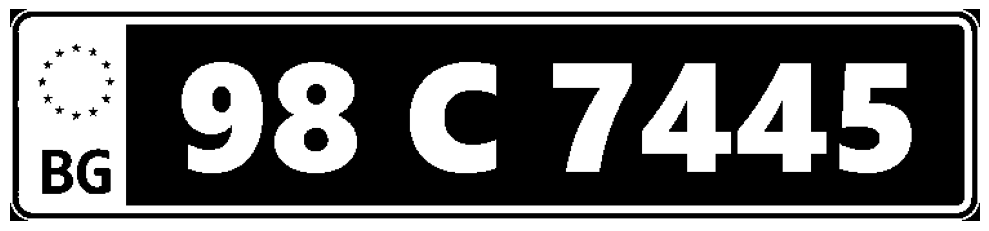

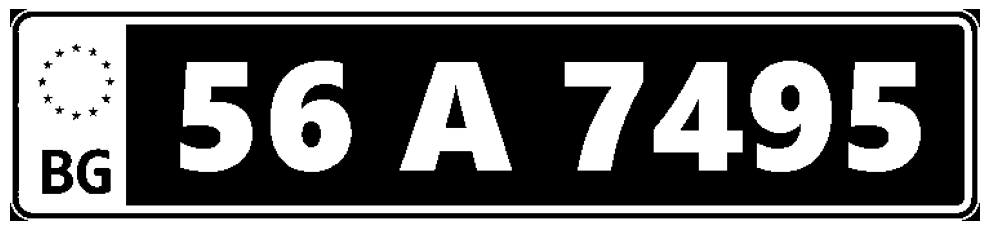

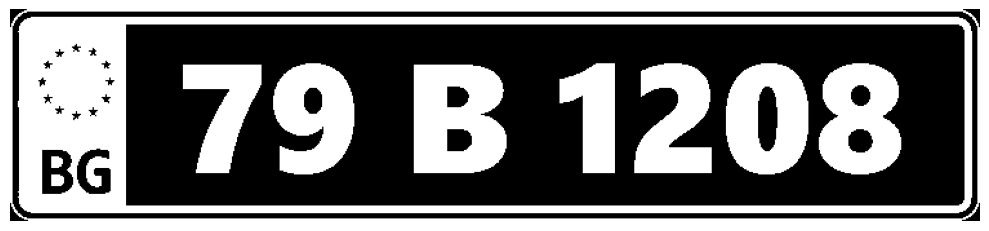

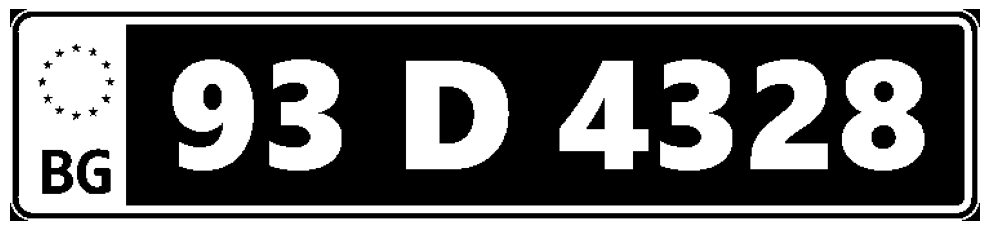

In [2]:
# Part 1_A :
import cv2
import matplotlib.pyplot as plt

def segment_characters(image_path):
    image = cv2.imread(image_path)
    
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filter out small contours (likely noise) and sort from left to right
    char_regions = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 10 and h > 20:  
            char_regions.append((x, y, w, h))
    char_regions = sorted(char_regions, key=lambda box: box[0])  # Sort by X-coordinate

    plt.figure(figsize=(10, 3))
    for idx, (x, y, w, h) in enumerate(char_regions):
        char_img = binary[y:y+h, x:x+w]
        plt.subplot(1, len(char_regions), idx + 1)
        plt.imshow(char_img, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

segment_characters("ideal/p1.jpg")
segment_characters("ideal/p2.jpg")
segment_characters("ideal/p3.jpg")
segment_characters("ideal/p4.jpg")

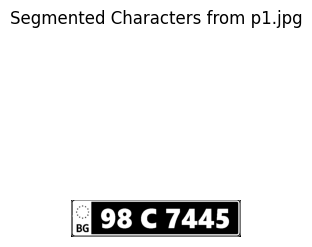

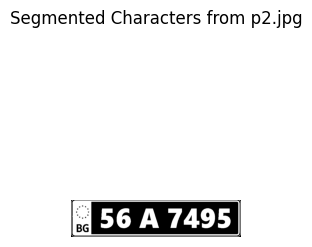

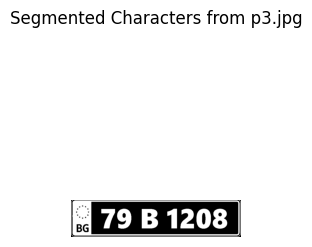

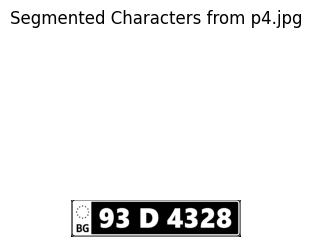

In [3]:
# Part 1_B :
import cv2
import matplotlib.pyplot as plt
import glob
import os

image_paths = sorted(glob.glob("ideal/p*.jpg"))

def segment_characters(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter and sort bounding boxes
    char_boxes = []
    h, w = thresh.shape
    for cnt in contours:
        x, y, cw, ch = cv2.boundingRect(cnt)
        if ch > h * 0.4 and cw > w * 0.02:
            char_boxes.append((x, y, cw, ch))
    char_boxes = sorted(char_boxes, key=lambda b: b[0])
    
    # Extract character images
    chars = [thresh[y:y+ch, x:x+cw] for (x, y, cw, ch) in char_boxes]
    return chars

for img_path in image_paths:
    image = cv2.imread(img_path)
    chars = segment_characters(image)
    
    num_chars = len(chars)
    fig, axs = plt.subplots(1, num_chars if num_chars > 1 else 1, figsize=(num_chars * 2, 4))
    fig.suptitle(f"Segmented Characters from {os.path.basename(img_path)}")
    
    if num_chars == 1:
        axs = [axs]
    
    for ax, char in zip(axs, chars):
        ax.imshow(char, cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

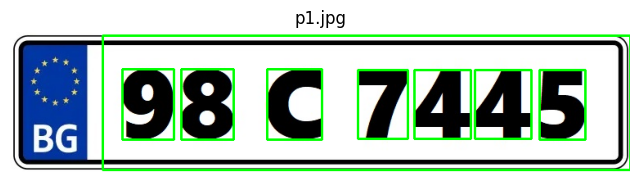

Recognized Plate : 98C7445
  Char 1: 9 (score=0.61)
  Char 2: 8 (score=0.61)
  Char 3: C (score=0.65)
  Char 4: 7 (score=0.72)
  Char 5: 4 (score=0.74)
  Char 6: 4 (score=0.74)
  Char 7: 5 (score=0.57)

----------------------------------------



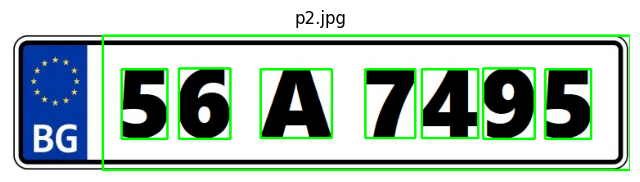

Recognized Plate : 56A7495
  Char 1: 5 (score=0.57)
  Char 2: 6 (score=0.62)
  Char 3: A (score=0.76)
  Char 4: 7 (score=0.72)
  Char 5: 4 (score=0.74)
  Char 6: 9 (score=0.61)
  Char 7: 5 (score=0.57)

----------------------------------------



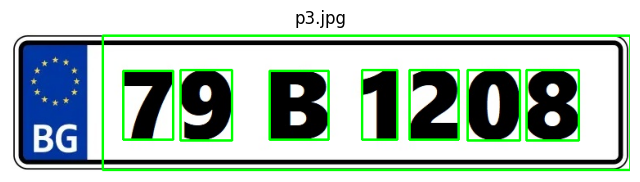

Recognized Plate : 79B1208
  Char 1: 7 (score=0.72)
  Char 2: 9 (score=0.61)
  Char 3: B (score=0.51)
  Char 4: 1 (score=0.66)
  Char 5: 2 (score=0.63)
  Char 6: 0 (score=0.60)
  Char 7: 8 (score=0.61)

----------------------------------------



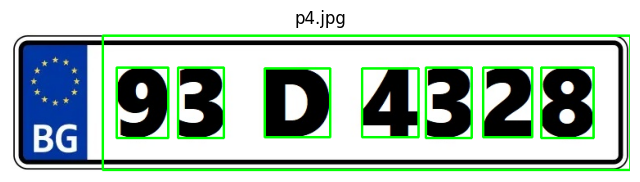

Recognized Plate : 93D4328
  Char 1: 9 (score=0.61)
  Char 2: 3 (score=0.60)
  Char 3: D (score=0.58)
  Char 4: 4 (score=0.74)
  Char 5: 3 (score=0.60)
  Char 6: 2 (score=0.63)
  Char 7: 8 (score=0.61)

----------------------------------------



In [ ]:
# Part 2 :
import cv2
import glob
import os
import matplotlib.pyplot as plt

ideal_folder   = "ideal"
letters_folder = "letters"
numbers_folder = "numbers"

templates = {}
for path in glob.glob(os.path.join(letters_folder, "*.jpg")) + glob.glob(os.path.join(numbers_folder, "*.jpg")):
    label = os.path.splitext(os.path.basename(path))[0]
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    _, tmpl = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    templates[label] = tmpl

def segment_characters(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    
    x0 = int(w * 0.15)
    roi = gray[:, x0:]
    
    # Reverse binarization: white character, black background
    _, thresh = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    clean = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    
    # Finding the contour
    cnts, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in cnts:
        x, y, cw, ch = cv2.boundingRect(c)
        if ch > h*0.4 and cw > w*0.03:
            boxes.append((x, y, cw, ch))
    boxes = sorted(boxes, key=lambda b: b[0])
    
    chars = [clean[y:y+ch, x:x+cw] for x, y, cw, ch in boxes]
    return chars, boxes, x0

def recognize_plate(chars, templates):
    plate = ""
    details = []
    for ch_img in chars:
        best_char, best_val = None, -1
        for label, tmpl in templates.items():
            tmpl_rs = cv2.resize(tmpl, (ch_img.shape[1], ch_img.shape[0]))
            res = cv2.matchTemplate(ch_img, tmpl_rs, cv2.TM_CCOEFF_NORMED)
            val = res.max()
            if val > best_val:
                best_val, best_char = val, label
        plate += best_char if best_char else "?"
        details.append((best_char, best_val))
    return plate, details

for path in sorted(glob.glob(os.path.join(ideal_folder, "p*.jpg"))):
    img = cv2.imread(path)
    chars, boxes, x0 = segment_characters(img)
    
    vis = img.copy()
    for x, y, cw, ch in boxes:
        cv2.rectangle(vis, (x+x0, y), (x+x0+cw, y+ch), (0,255,0), 2)
    
    plt.figure(figsize=(8,4))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(os.path.basename(path))
    plt.axis('off')
    plt.show()
    
    plate, corrs = recognize_plate(chars, templates)
    plate = plate[1:]
    corrs = corrs[1:]
    print(f"Recognized Plate : {plate}")
    for i, (c, v) in enumerate(corrs, 1):
        print(f"  Char {i}: {c} (score={v:.2f})")
    print("\n" + "-"*40 + "\n")


--------------------------------------------------
Processing p1.jpg


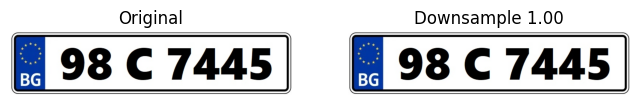

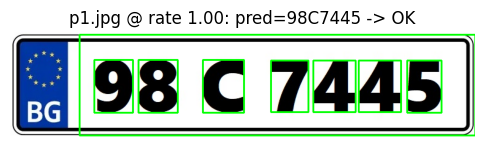

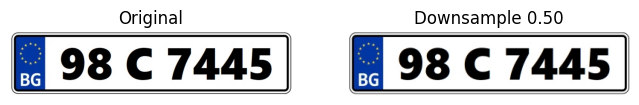

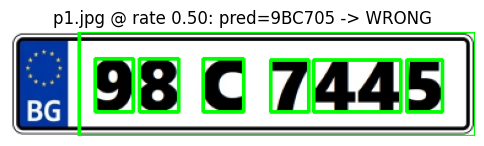

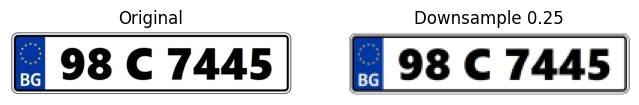

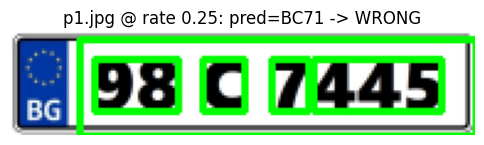

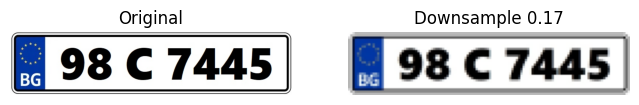

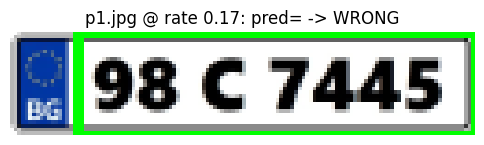

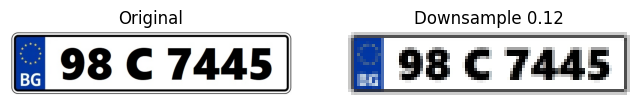

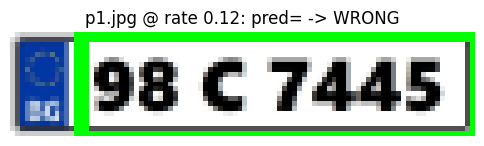

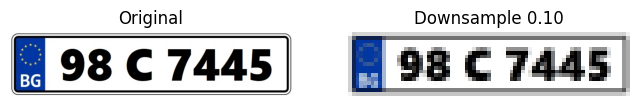

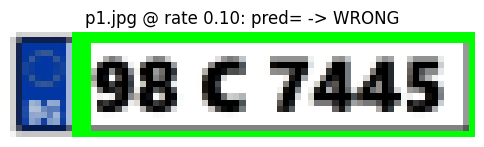


Results for p1.jpg
  Rate 1.00: Correct
  Rate 0.50: Incorrect
  Rate 0.25: Incorrect
  Rate 0.17: Incorrect
  Rate 0.12: Incorrect
  Rate 0.10: Incorrect
Minimum rate for correct recognition: 1.00


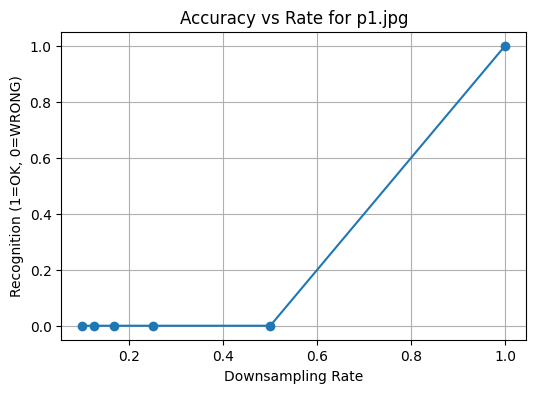


--------------------------------------------------
Processing p2.jpg


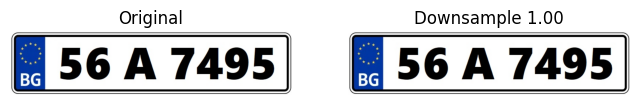

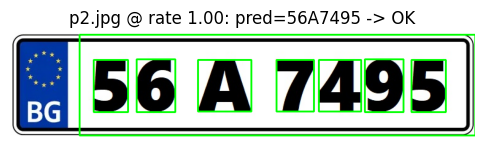

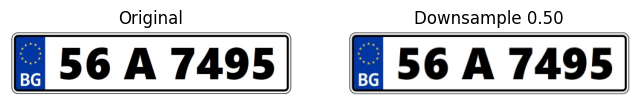

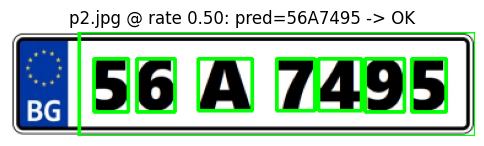

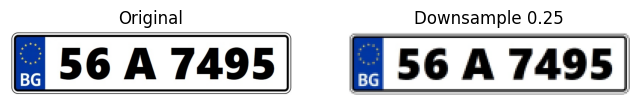

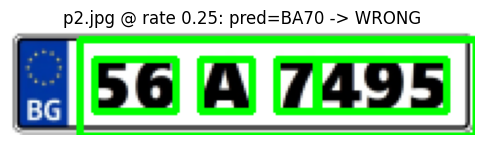

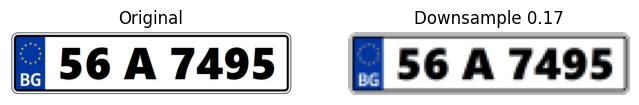

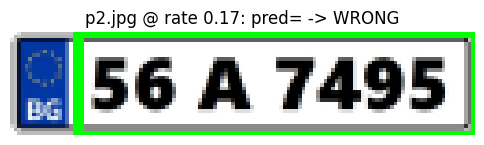

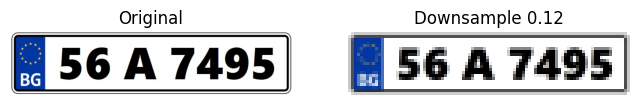

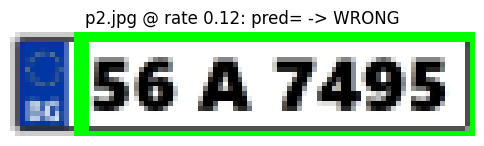

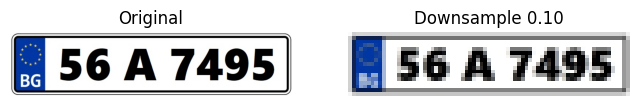

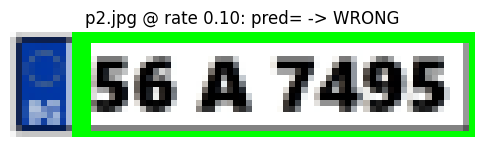


Results for p2.jpg
  Rate 1.00: Correct
  Rate 0.50: Correct
  Rate 0.25: Incorrect
  Rate 0.17: Incorrect
  Rate 0.12: Incorrect
  Rate 0.10: Incorrect
Minimum rate for correct recognition: 0.50


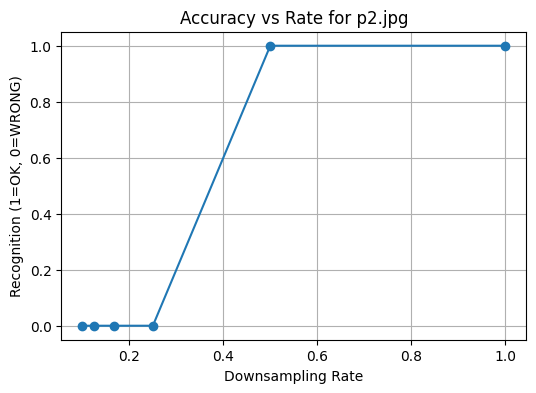


--------------------------------------------------
Processing p3.jpg


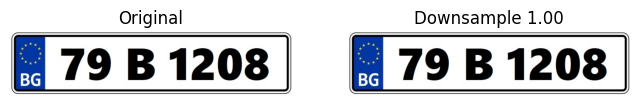

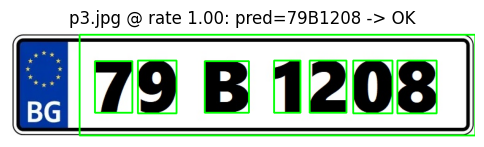

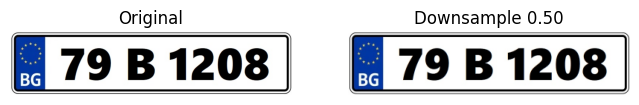

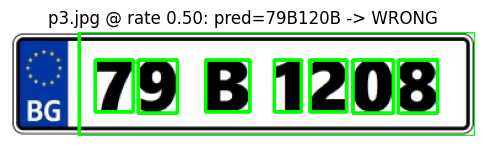

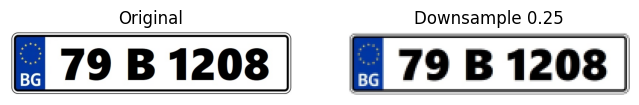

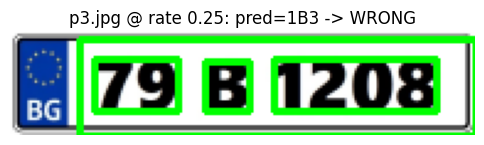

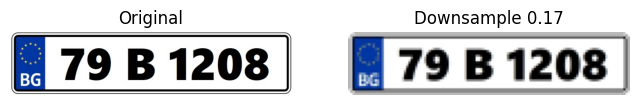

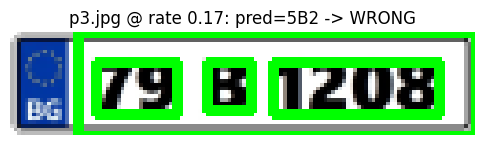

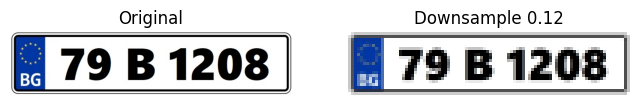

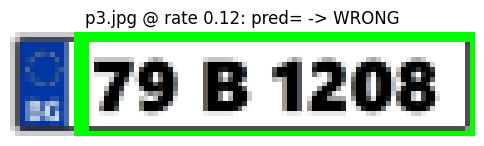

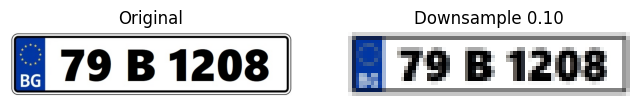

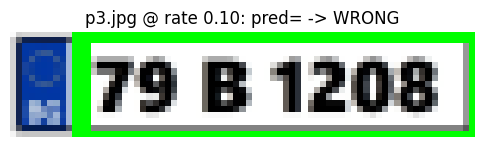


Results for p3.jpg
  Rate 1.00: Correct
  Rate 0.50: Incorrect
  Rate 0.25: Incorrect
  Rate 0.17: Incorrect
  Rate 0.12: Incorrect
  Rate 0.10: Incorrect
Minimum rate for correct recognition: 1.00


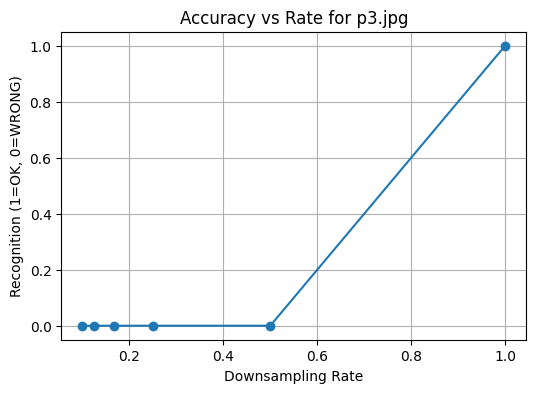


--------------------------------------------------
Processing p4.jpg


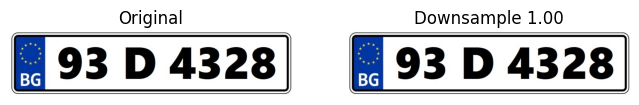

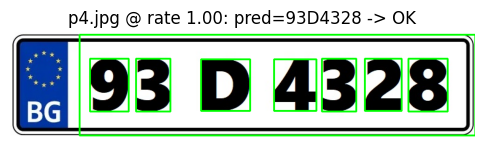

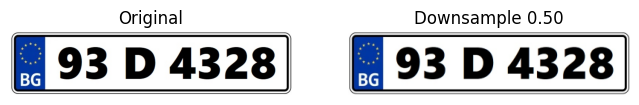

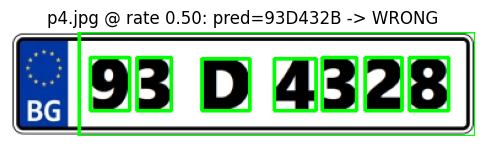

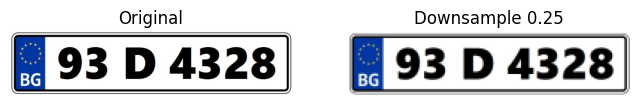

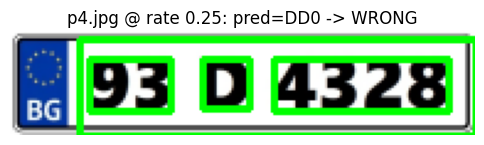

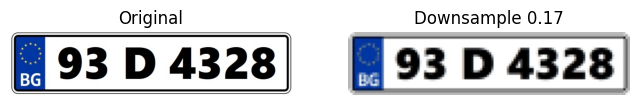

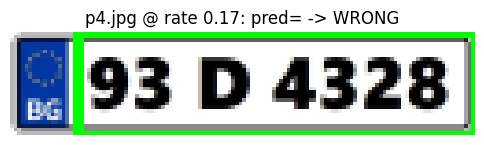

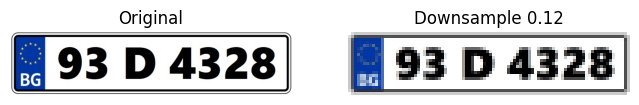

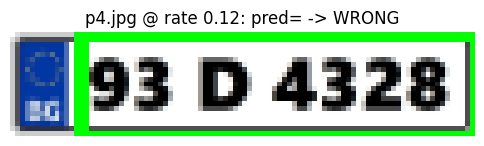

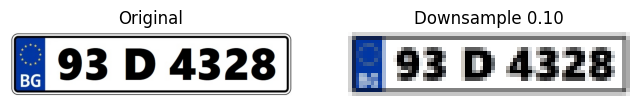

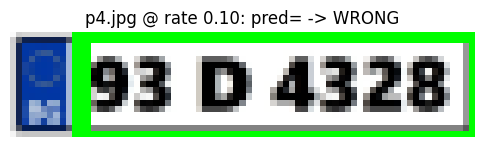


Results for p4.jpg
  Rate 1.00: Correct
  Rate 0.50: Incorrect
  Rate 0.25: Incorrect
  Rate 0.17: Incorrect
  Rate 0.12: Incorrect
  Rate 0.10: Incorrect
Minimum rate for correct recognition: 1.00


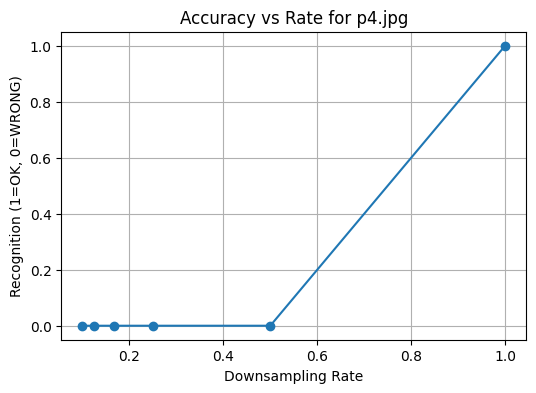


Final Summary:
p1.jpg: min rate = 1.00
p2.jpg: min rate = 0.50
p3.jpg: min rate = 1.00
p4.jpg: min rate = 1.00


In [5]:
# Part 3 : 
import cv2
import glob
import os
import matplotlib.pyplot as plt

ideal_folder   = "ideal"
letters_folder = "letters"
numbers_folder = "numbers"

# Downsampling rates for testing
rates = [1/1, 1/2, 1/4, 1/6, 1/8, 1/10]

templates = {}
for path in glob.glob(os.path.join(letters_folder, "*.jpg")) + glob.glob(os.path.join(numbers_folder, "*.jpg")):
    label = os.path.splitext(os.path.basename(path))[0]
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    _, tmpl = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    templates[label] = tmpl

def segment_characters(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    x0 = int(w * 0.15)
    roi = gray[:, x0:]
    _, thresh = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    clean = cv2.morphologyEx(thresh,
                             cv2.MORPH_CLOSE,
                             cv2.getStructuringElement(cv2.MORPH_RECT, (5,5)))
    cnts, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = [(x,y,cw,ch) for c in cnts
             for x,y,cw,ch in [cv2.boundingRect(c)]
             if ch > h*0.4 and cw > w*0.03]
    boxes = sorted(boxes, key=lambda b: b[0])
    return clean, [(x + x0, y, cw, ch) for x,y,cw,ch in boxes], [clean[y:y+ch, x:x+cw] for x,y,cw,ch in boxes]

def recognize_plate(chars):
    plate = ""
    for ch_img in chars:
        best_char, best_val = None, -1
        for label, tmpl in templates.items():
            tmpl_rs = cv2.resize(tmpl, (ch_img.shape[1], ch_img.shape[0]))
            res = cv2.matchTemplate(ch_img, tmpl_rs, cv2.TM_CCOEFF_NORMED)
            val = res.max()
            if val > best_val:
                best_val, best_char = val, label
        plate += best_char or "?"
    return plate[1:]  

ground_truth = {
    "p1.jpg": "98C7445",
    "p2.jpg": "56A7495",
    "p3.jpg": "79B1208",
    "p4.jpg": "93D4328"
}

all_results = {}

for fname, true_text in ground_truth.items():
    print("\n" + "-"*50)
    print(f"Processing {fname}")
    img_orig = cv2.imread(os.path.join(ideal_folder, fname))
    h0, w0 = img_orig.shape[:2]
    
    results = []
    for r in rates:
        # Apply downsampling
        img_ds = cv2.resize(img_orig, (int(w0*r), int(h0*r)), interpolation=cv2.INTER_AREA)
        
        plt.figure(figsize=(8,3))
        plt.subplot(1,2,1)
        plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
        plt.title("Original")
        plt.axis('off')
        plt.subplot(1,2,2)
        plt.imshow(cv2.cvtColor(img_ds, cv2.COLOR_BGR2RGB))
        plt.title(f"Downsample {r:.2f}")
        plt.axis('off')
        plt.show()
        
        # Segmentation and detection
        clean, boxes, chars = segment_characters(img_ds)
        pred = recognize_plate(chars)
        correct = (pred == true_text)
        results.append(correct)
        
        # Show bounding box and result
        vis = img_ds.copy()
        for x, y, cw, ch in boxes:
            cv2.rectangle(vis, (x, y), (x+cw, y+ch), (0,255,0), 2)
        plt.figure(figsize=(6,3))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title(f"{fname} @ rate {r:.2f}: pred={pred} -> {'OK' if correct else 'WRONG'}")
        plt.axis('off')
        plt.show()

    # Calculating accuracy and minimum acceptable rate
    valid_rates = [r for r, ok in zip(rates, results) if ok]
    min_rate = min(valid_rates) if valid_rates else None

    print("\nResults for", fname)
    for r, ok in zip(rates, results):
        print(f"  Rate {r:.2f}: {'Correct' if ok else 'Incorrect'}")
    if min_rate:
        print(f"Minimum rate for correct recognition: {min_rate:.2f}")
    else:
        print("No rate achieved correct recognition.")
    
    plt.figure(figsize=(6,4))
    plt.plot(rates, [int(x) for x in results], marker='o')
    plt.xlabel("Downsampling Rate")
    plt.ylabel("Recognition (1=OK, 0=WRONG)")
    plt.title(f"Accuracy vs Rate for {fname}")
    plt.grid(True)
    plt.show()
    
    all_results[fname] = {"rates": rates, "results": results, "min_rate": min_rate}

print("\nFinal Summary:")
for fname, data in all_results.items():
    print(f"{fname}: min rate = {data['min_rate']:.2f}" if data['min_rate'] else f"{fname}: no correct rate")